# Google Ads Data Analysis

This notebook loads and analyzes Google Ads data from DynamoDB.

## Features:
- Load Google Ads events from DynamoDB
- Data exploration and summary statistics
- Visualization of key metrics
- Fraud detection analysis
- Campaign performance analysis


In [18]:
# Import required libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
from decimal import Decimal
import boto3
from botocore.exceptions import ClientError
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Add project root to path for imports
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## Configuration

Set your DynamoDB table name and other configuration options.


In [19]:
# Configuration
TABLE_NAME = os.environ.get('TABLE_NAME') or os.environ.get('DYNAMODB_TABLE_NAME') or 'fraudguard-events-dev'
AWS_REGION = 'us-east-1'
MAX_RECORDS = 1000  # Limit number of records to load (set to None for all)

print(f"📊 Configuration:")
print(f"   Table Name: {TABLE_NAME}")
print(f"   AWS Region: {AWS_REGION}")
print(f"   Max Records: {MAX_RECORDS if MAX_RECORDS else 'All'}")


📊 Configuration:
   Table Name: fraudguard-events-dev
   AWS Region: us-east-1
   Max Records: 1000


## Load Data from DynamoDB

Load Google Ads events from DynamoDB table.


In [20]:
def convert_decimal_to_float(obj):
    """Convert Decimal to float for JSON serialization"""
    if isinstance(obj, Decimal):
        return float(obj)
    elif isinstance(obj, dict):
        return {k: convert_decimal_to_float(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_decimal_to_float(item) for item in obj]
    return obj

def load_google_ads_data(table_name, limit=None):
    """
    Load Google Ads data from DynamoDB
    
    Args:
        table_name: DynamoDB table name
        limit: Maximum number of records to load
    
    Returns:
        DataFrame with Google Ads event data
    """
    try:
        dynamodb = boto3.resource('dynamodb', region_name=AWS_REGION)
        table = dynamodb.Table(table_name)
        
        print(f"🔍 Scanning DynamoDB table: {table_name}...")
        
        # Scan table and filter for Google Ads events
        items = []
        response = table.scan(
            FilterExpression='#src = :source OR begins_with(#src, :prefix)',
            ExpressionAttributeNames={'#src': 'source'},
            ExpressionAttributeValues={
                ':source': 'google_ads',
                ':prefix': 'google_ads'
            }
        )
        items.extend(response.get('Items', []))
        
        # Handle pagination
        while 'LastEvaluatedKey' in response:
            if limit and len(items) >= limit:
                break
            response = table.scan(
                FilterExpression='#src = :source OR begins_with(#src, :prefix)',
                ExpressionAttributeNames={'#src': 'source'},
                ExpressionAttributeValues={
                    ':source': 'google_ads',
                    ':prefix': 'google_ads'
                },
                ExclusiveStartKey=response['LastEvaluatedKey']
            )
            items.extend(response.get('Items', []))
            
            if len(items) % 100 == 0:
                print(f"   Loaded {len(items)} records...")
        
        # Limit results if specified
        if limit:
            items = items[:limit]
        
        # Convert Decimals to floats
        items = [convert_decimal_to_float(item) for item in items]
        
        # Convert to DataFrame
        df = pd.DataFrame(items)
        
        print(f"✅ Loaded {len(df):,} records from DynamoDB")
        
        return df
        
    except ClientError as e:
        error_code = e.response.get('Error', {}).get('Code', 'Unknown')
        if error_code == 'ResourceNotFoundException':
            raise ValueError(f"DynamoDB table not found: {table_name}")
        else:
            raise ValueError(f"Error loading from DynamoDB: {error_code} - {str(e)}")

# Load the data
df = load_google_ads_data(TABLE_NAME, limit=MAX_RECORDS)


🔍 Scanning DynamoDB table: fraudguard-events-dev...
✅ Loaded 1,000 records from DynamoDB


In [21]:
print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n🔍 First few rows:")
display(df)


📊 Dataset Shape: 1,000 rows × 23 columns

📋 Columns (23):
    1. ctr
    2. created_at
    3. target_id
    4. gclid
    5. primary_fraud_type
    6. shifted_date
    7. fraud_signals
    8. cost_micros
    9. timestamp
   10. source
   11. is_fraud
   12. ad_group_id
   13. campaign_id
   14. conversions
   15. campaign_name
   16. updated_at
   17. event_type
   18. clicks
   19. event_id
   20. impressions
   21. original_date
   22. fraud_score
   23. keyword

🔍 First few rows:


,ctr,created_at,target_id,gclid,primary_fraud_type,shifted_date,fraud_signals,cost_micros,timestamp,source,...,conversions,campaign_name,updated_at,event_type,clicks,event_id,impressions,original_date,fraud_score,keyword
0,0.150000,2025-11-12T23:46:03.183154+00:00,,API-15973228203-1730602219-2-eff5b89c,legitimate,2024-11-03,[],7293333.0,1.730602e+09,google_ads_api,...,0.0,US - Social - NB,2025-11-12T23:46:03.183158+00:00,click,1.0,google-ads-historical-15973228203-1730602219-2...,6.0,2023-11-03,0.0,Snapchat ads
1,0.280000,2025-11-12T23:46:03.053662+00:00,,API-15973228068-1732774395-0-8395447f,legitimate,2024-11-28,[],4598571.0,1.732774e+09,google_ads_api,...,0.0,US - Marin - B,2025-11-12T23:46:03.053667+00:00,click,1.0,google-ads-historical-15973228068-1732774395-0...,3.0,2023-11-28,0.0,marinsoftware
2,0.043956,2025-11-12T23:46:03.245746+00:00,,API-18395768345-1739772840-4-b081a7eb,legitimate,2025-02-17,[],1103333.0,1.739773e+09,google_ads_api,...,0.0,US - TikTok - NB,2025-11-12T23:46:03.245750+00:00,click,1.0,google-ads-historical-18395768345-1739772840-4...,22.0,2024-02-17,0.0,tiktok business manager
3,0.027907,2025-11-12T23:46:02.864605+00:00,,API-15973228050-1742594956-1-0661d77d,legitimate,2025-03-21,[],14885684.0,1.742595e+09,google_ads_api,...,0.0,US+UK - Competitors - NB,2025-11-12T23:46:02.864609+00:00,click,1.0,google-ads-historical-15973228050-1742594956-1...,35.0,2024-03-21,0.0,SA360
4,0.020833,2025-11-12T23:46:02.848800+00:00,,API-15973228050-1739261884-3-1a94b0ec,legitimate,2025-02-11,[],11040000.0,1.739262e+09,google_ads_api,...,0.0,US+UK - Competitors - NB,2025-11-12T23:46:02.848804+00:00,click,1.0,google-ads-historical-15973228050-1739261884-3...,48.0,2024-02-11,0.0,kenshoo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.024465,2025-11-12T23:46:02.856409+00:00,,API-15973228050-1740615312-6-1c342a1c,legitimate,2025-02-27,[],17202500.0,1.740615e+09,google_ads_api,...,0.0,US+UK - Competitors - NB,2025-11-12T23:46:02.856413+00:00,click,1.0,google-ads-historical-15973228050-1740615312-6...,40.0,2024-02-27,0.0,search ads 360
996,0.018367,2025-11-12T23:46:02.859019+00:00,,API-15973228050-1741163173-5-c046200a,legitimate,2025-03-05,[],16155555.0,1.741163e+09,google_ads_api,...,0.0,US+UK - Competitors - NB,2025-11-12T23:46:02.859023+00:00,click,1.0,google-ads-historical-15973228050-1741163173-5...,54.0,2024-03-05,0.0,google adwords marketing
997,0.282051,2025-11-12T23:46:03.085729+00:00,,API-15973228068-1744693237-10-2eadac47,legitimate,2025-04-15,[],3823636.0,1.744693e+09,google_ads_api,...,0.0,US - Marin - B,2025-11-12T23:46:03.085733+00:00,click,1.0,google-ads-historical-15973228068-1744693237-1...,3.0,2024-04-15,0.0,marinsoftware.com
998,0.005381,2025-11-12T23:46:03.260817+00:00,,API-20594087693-1730571235-64-7af80fb8,legitimate,2024-11-02,[],593957.0,1.730571e+09,google_ads_api,...,0.0,GDN_Rmkt_ProductVisitors_2023,2025-11-12T23:46:03.260821+00:00,click,1.0,google-ads-historical-20594087693-1730571235-6...,185.0,2023-11-02,0.0,


In [15]:
# Data types and missing values
print("📊 Data Types and Missing Values:")
info_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
info_df


📊 Data Types and Missing Values:


,Column,Data Type,Non-Null Count,Null Count,Null Percentage
ctr,ctr,float64,1000,0,0.0
created_at,created_at,object,1000,0,0.0
target_id,target_id,object,1000,0,0.0
gclid,gclid,object,1000,0,0.0
primary_fraud_type,primary_fraud_type,object,1000,0,0.0
shifted_date,shifted_date,object,1000,0,0.0
fraud_signals,fraud_signals,object,1000,0,0.0
cost_micros,cost_micros,float64,1000,0,0.0
timestamp,timestamp,float64,1000,0,0.0
source,source,object,1000,0,0.0


## Data Preprocessing

Clean and prepare the data for analysis.


In [22]:
# Convert timestamp to datetime
if 'timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
    df['date'] = df['datetime'].dt.date
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.day_name()
    print("✅ Converted timestamp to datetime")

# Convert cost_micros to dollars
if 'cost_micros' in df.columns:
    df['cost_usd'] = df['cost_micros'] / 1_000_000
    print("✅ Converted cost_micros to USD")

# Ensure numeric columns are properly typed
numeric_cols = ['clicks', 'impressions', 'conversions', 'ctr', 'fraud_score', 'cost_usd']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ Data preprocessing complete")

display(df)


✅ Converted timestamp to datetime
✅ Converted cost_micros to USD
✅ Data preprocessing complete


,ctr,created_at,target_id,gclid,primary_fraud_type,shifted_date,fraud_signals,cost_micros,timestamp,source,...,event_id,impressions,original_date,fraud_score,keyword,datetime,date,hour,day_of_week,cost_usd
0,0.150000,2025-11-12T23:46:03.183154+00:00,,API-15973228203-1730602219-2-eff5b89c,legitimate,2024-11-03,[],7293333.0,1.730602e+09,google_ads_api,...,google-ads-historical-15973228203-1730602219-2...,6.0,2023-11-03,0.0,Snapchat ads,2024-11-03 02:50:19,2024-11-03,2,Sunday,7.293333
1,0.280000,2025-11-12T23:46:03.053662+00:00,,API-15973228068-1732774395-0-8395447f,legitimate,2024-11-28,[],4598571.0,1.732774e+09,google_ads_api,...,google-ads-historical-15973228068-1732774395-0...,3.0,2023-11-28,0.0,marinsoftware,2024-11-28 06:13:15,2024-11-28,6,Thursday,4.598571
2,0.043956,2025-11-12T23:46:03.245746+00:00,,API-18395768345-1739772840-4-b081a7eb,legitimate,2025-02-17,[],1103333.0,1.739773e+09,google_ads_api,...,google-ads-historical-18395768345-1739772840-4...,22.0,2024-02-17,0.0,tiktok business manager,2025-02-17 06:14:00,2025-02-17,6,Monday,1.103333
3,0.027907,2025-11-12T23:46:02.864605+00:00,,API-15973228050-1742594956-1-0661d77d,legitimate,2025-03-21,[],14885684.0,1.742595e+09,google_ads_api,...,google-ads-historical-15973228050-1742594956-1...,35.0,2024-03-21,0.0,SA360,2025-03-21 22:09:16,2025-03-21,22,Friday,14.885684
4,0.020833,2025-11-12T23:46:02.848800+00:00,,API-15973228050-1739261884-3-1a94b0ec,legitimate,2025-02-11,[],11040000.0,1.739262e+09,google_ads_api,...,google-ads-historical-15973228050-1739261884-3...,48.0,2024-02-11,0.0,kenshoo,2025-02-11 08:18:04,2025-02-11,8,Tuesday,11.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.024465,2025-11-12T23:46:02.856409+00:00,,API-15973228050-1740615312-6-1c342a1c,legitimate,2025-02-27,[],17202500.0,1.740615e+09,google_ads_api,...,google-ads-historical-15973228050-1740615312-6...,40.0,2024-02-27,0.0,search ads 360,2025-02-27 00:15:12,2025-02-27,0,Thursday,17.202500
996,0.018367,2025-11-12T23:46:02.859019+00:00,,API-15973228050-1741163173-5-c046200a,legitimate,2025-03-05,[],16155555.0,1.741163e+09,google_ads_api,...,google-ads-historical-15973228050-1741163173-5...,54.0,2024-03-05,0.0,google adwords marketing,2025-03-05 08:26:13,2025-03-05,8,Wednesday,16.155555
997,0.282051,2025-11-12T23:46:03.085729+00:00,,API-15973228068-1744693237-10-2eadac47,legitimate,2025-04-15,[],3823636.0,1.744693e+09,google_ads_api,...,google-ads-historical-15973228068-1744693237-1...,3.0,2024-04-15,0.0,marinsoftware.com,2025-04-15 05:00:37,2025-04-15,5,Tuesday,3.823636
998,0.005381,2025-11-12T23:46:03.260817+00:00,,API-20594087693-1730571235-64-7af80fb8,legitimate,2024-11-02,[],593957.0,1.730571e+09,google_ads_api,...,google-ads-historical-20594087693-1730571235-6...,185.0,2023-11-02,0.0,,2024-11-02 18:13:55,2024-11-02,18,Saturday,0.593957


## Summary Statistics

Key statistics for numeric columns.


In [9]:
# Summary statistics for numeric columns
numeric_summary = df.select_dtypes(include=[np.number]).describe()
print("📊 Summary Statistics:")
numeric_summary


📊 Summary Statistics:


,ctr,cost_micros,timestamp,conversions,clicks,impressions,fraud_score,hour,cost_usd
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.0,1000.000000,1000.0,1000.000000,1000.000000
mean,0.082911,9.269546e+06,1.741732e+09,0.014000,1.0,47.941000,0.0,11.166000,9.269546
std,0.128803,8.979228e+06,7.735884e+06,0.117549,0.0,60.181603,0.0,6.869908,8.979228
min,0.002674,3.438460e+05,1.730482e+09,0.000000,1.0,1.000000,0.0,0.000000,0.343846
25%,0.022094,1.928333e+06,1.735833e+09,0.000000,1.0,15.000000,0.0,5.000000,1.928333
50%,0.034426,8.140000e+06,1.740857e+09,0.000000,1.0,29.000000,0.0,11.000000,8.140000
75%,0.064591,1.390553e+07,1.747241e+09,0.000000,1.0,45.000000,0.0,17.000000,13.905526
max,0.800000,1.045200e+08,1.761783e+09,1.000000,1.0,374.000000,0.0,23.000000,104.520000


In [10]:
# Key metrics summary
print("📈 Key Metrics Summary:")
print(f"   Total Events: {len(df):,}")
print(f"   Total Clicks: {df['clicks'].sum():,.0f}" if 'clicks' in df.columns else "   Total Clicks: N/A")
print(f"   Total Impressions: {df['impressions'].sum():,.0f}" if 'impressions' in df.columns else "   Total Impressions: N/A")
print(f"   Total Conversions: {df['conversions'].sum():,.0f}" if 'conversions' in df.columns else "   Total Conversions: N/A")
print(f"   Total Cost: ${df['cost_usd'].sum():,.2f}" if 'cost_usd' in df.columns else "   Total Cost: N/A")
print(f"   Average Cost per Click: ${df['cost_usd'].mean():.2f}" if 'cost_usd' in df.columns else "   Average Cost per Click: N/A")
print(f"   Average CTR: {df['ctr'].mean():.4f}" if 'ctr' in df.columns else "   Average CTR: N/A")
print(f"   Fraudulent Events: {df['is_fraud'].sum():,}" if 'is_fraud' in df.columns else "   Fraudulent Events: N/A")
print(f"   Average Fraud Score: {df['fraud_score'].mean():.4f}" if 'fraud_score' in df.columns else "   Average Fraud Score: N/A")


📈 Key Metrics Summary:
   Total Events: 1,000
   Total Clicks: 1,000
   Total Impressions: 47,941
   Total Conversions: 14
   Total Cost: $9,269.55
   Average Cost per Click: $9.27
   Average CTR: 0.0829
   Fraudulent Events: 0
   Average Fraud Score: 0.0000


## Campaign Analysis

Analyze performance by campaign.


In [27]:
# Campaign performance summary
if 'campaign_name' in df.columns:
    campaign_stats = df.groupby('campaign_name').agg({
        'clicks': 'sum',
        'impressions': 'sum',
        'conversions': 'sum',
        'cost_usd': 'sum',
        'fraud_score': 'mean',
        'is_fraud': 'sum'
    }).round(2)
    
    campaign_stats['ctr'] = (campaign_stats['clicks'] / campaign_stats['impressions'] * 100).round(2)
    campaign_stats['cpc'] = (campaign_stats['cost_usd'] / campaign_stats['clicks']).round(2)
    campaign_stats['conversion_rate'] = (campaign_stats['conversions'] / campaign_stats['clicks'] * 100).round(2)
    
    campaign_stats = campaign_stats.sort_values('cost_usd', ascending=False)
    
    print(f"📊 Campaign Performance (Top {min(10, len(campaign_stats))} by Cost):")
    campaign_stats.head(10)


📊 Campaign Performance (Top 10 by Cost):


## Visualizations

Visualize key metrics and patterns.


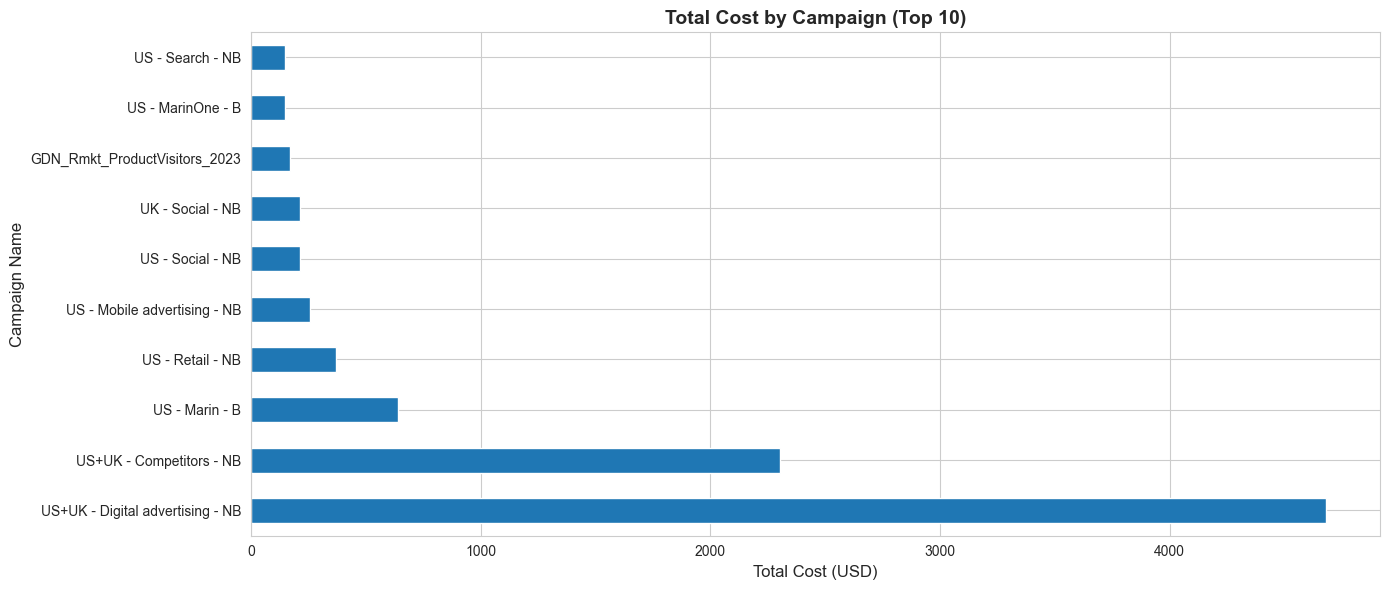

In [25]:
# 1. Cost distribution by campaign
if 'campaign_name' in df.columns and 'cost_usd' in df.columns:
    plt.figure(figsize=(14, 6))
    campaign_costs = df.groupby('campaign_name')['cost_usd'].sum().sort_values(ascending=False).head(10)
    campaign_costs.plot(kind='barh')
    plt.title('Total Cost by Campaign (Top 10)', fontsize=14, fontweight='bold')
    plt.xlabel('Total Cost (USD)', fontsize=12)
    plt.ylabel('Campaign Name', fontsize=12)
    plt.tight_layout()
    plt.show()


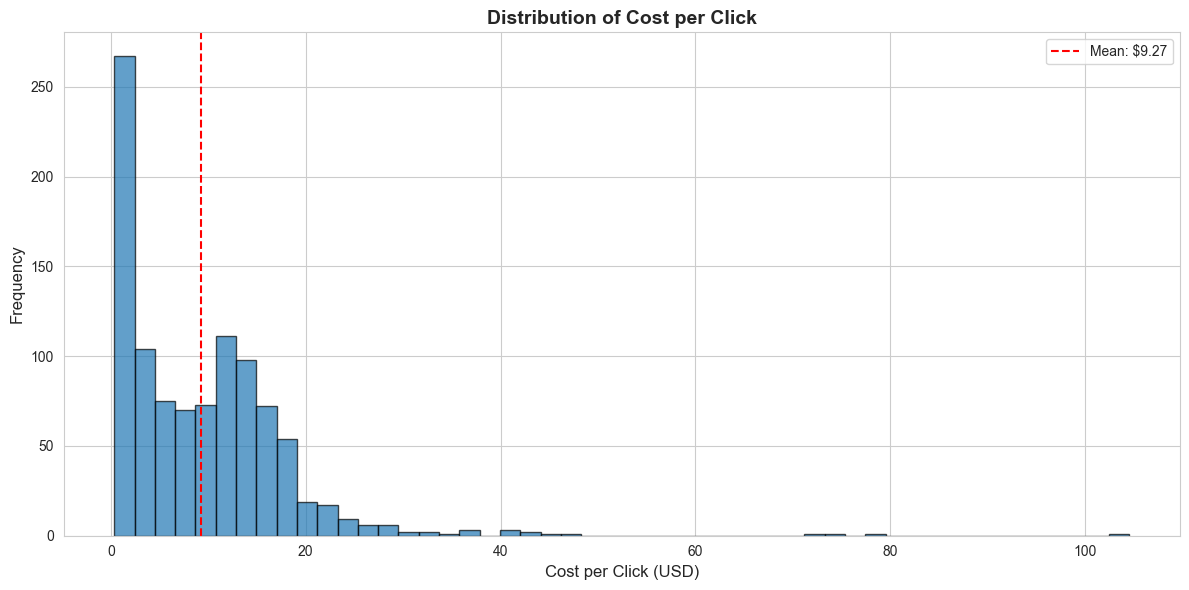

In [28]:
# 2. Cost per click distribution
if 'cost_usd' in df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(df['cost_usd'], bins=50, edgecolor='black', alpha=0.7)
    plt.title('Distribution of Cost per Click', fontsize=14, fontweight='bold')
    plt.xlabel('Cost per Click (USD)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.axvline(df['cost_usd'].mean(), color='red', linestyle='--', label=f'Mean: ${df["cost_usd"].mean():.2f}')
    plt.legend()
    plt.tight_layout()
    plt.show()


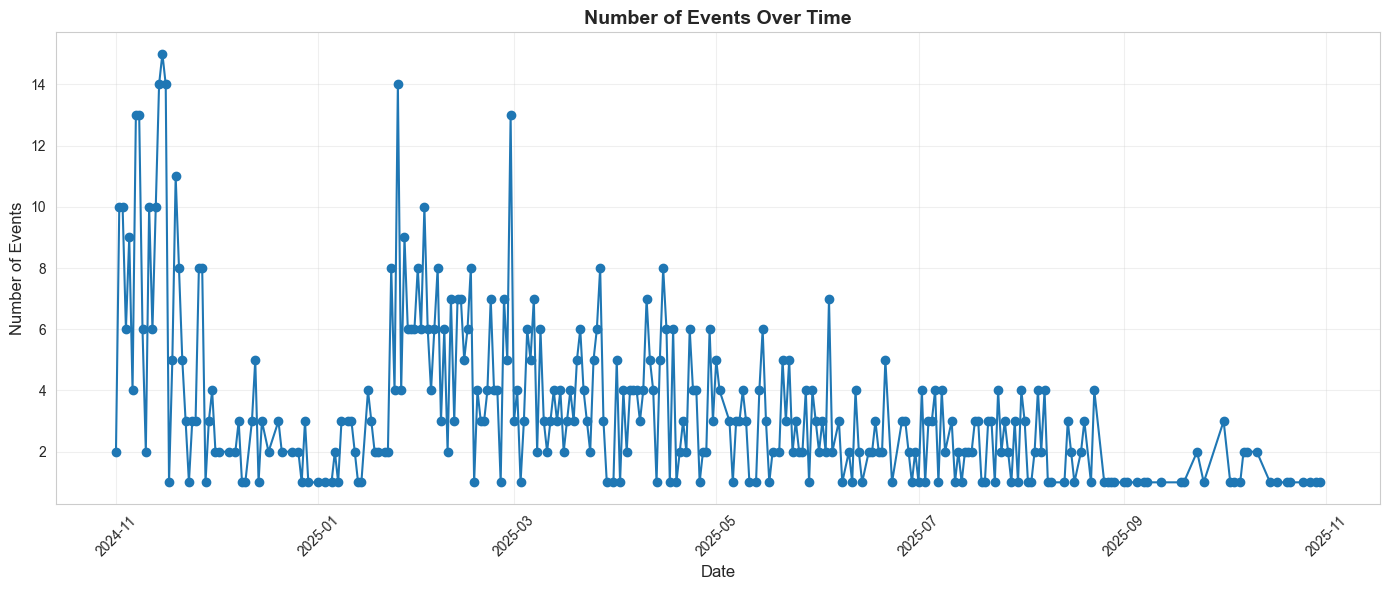

In [29]:
# 3. Events over time
if 'datetime' in df.columns:
    df_time = df.groupby(df['datetime'].dt.date).size()
    
    plt.figure(figsize=(14, 6))
    df_time.plot(kind='line', marker='o')
    plt.title('Number of Events Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Events', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


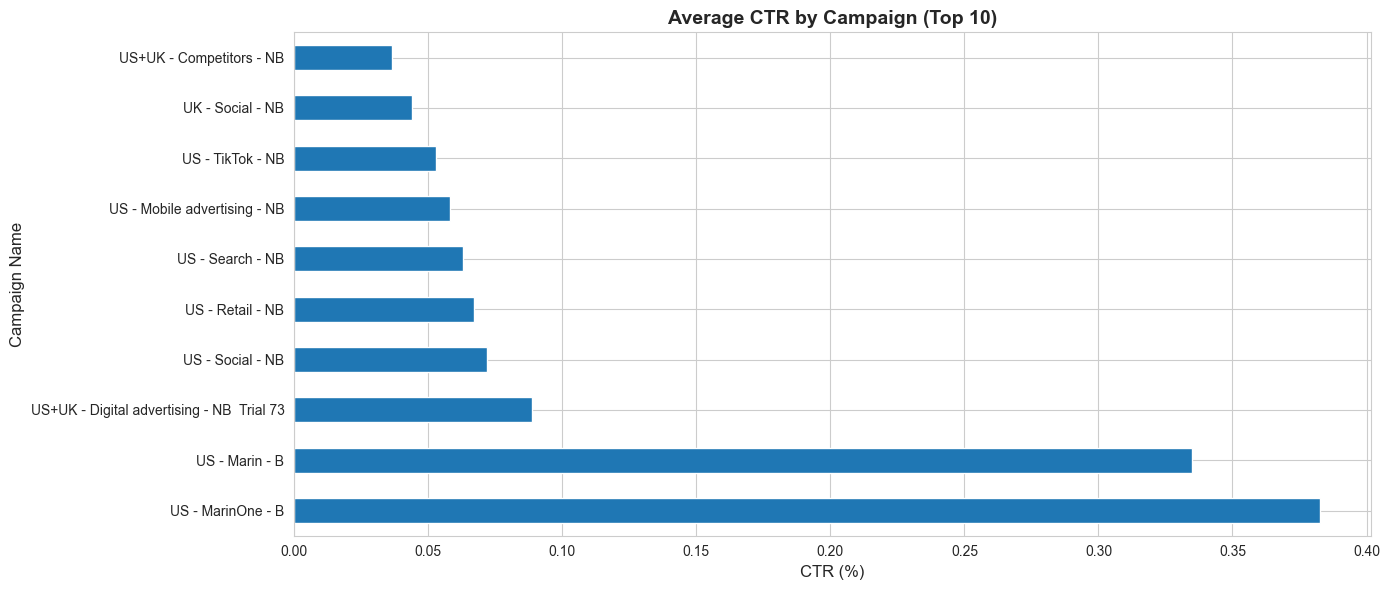

In [30]:
# 4. CTR by campaign
if 'campaign_name' in df.columns and 'ctr' in df.columns:
    campaign_ctr = df.groupby('campaign_name')['ctr'].mean().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(14, 6))
    campaign_ctr.plot(kind='barh')
    plt.title('Average CTR by Campaign (Top 10)', fontsize=14, fontweight='bold')
    plt.xlabel('CTR (%)', fontsize=12)
    plt.ylabel('Campaign Name', fontsize=12)
    plt.tight_layout()
    plt.show()


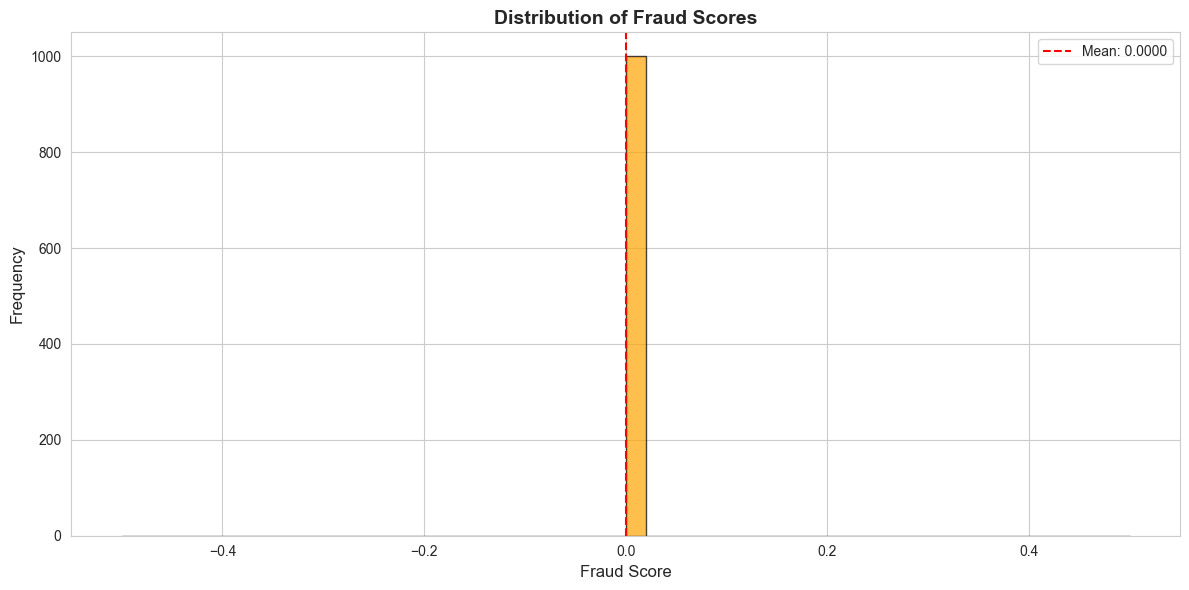

In [31]:
# 5. Fraud score distribution
if 'fraud_score' in df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(df['fraud_score'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    plt.title('Distribution of Fraud Scores', fontsize=14, fontweight='bold')
    plt.xlabel('Fraud Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.axvline(df['fraud_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["fraud_score"].mean():.4f}')
    plt.legend()
    plt.tight_layout()
    plt.show()


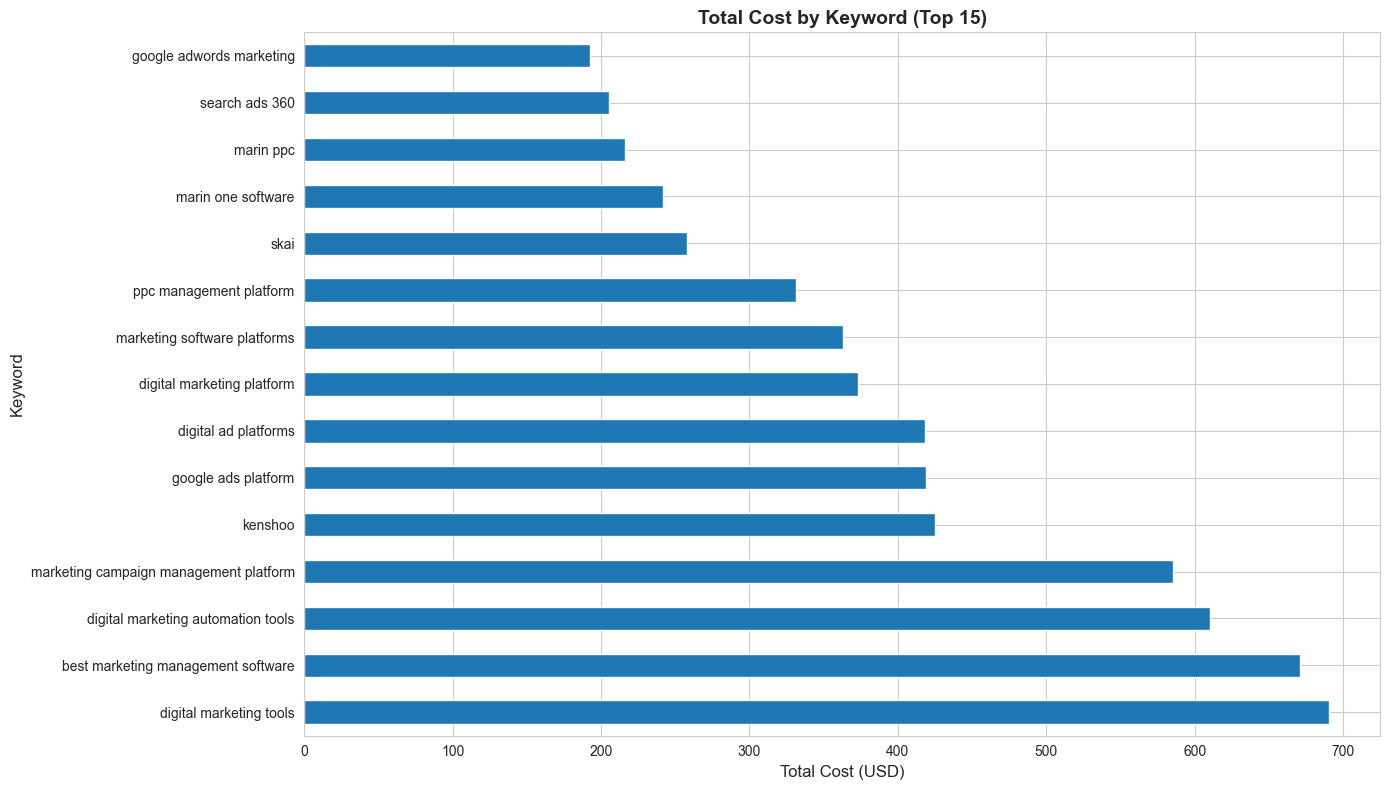

In [32]:
# 6. Top keywords by cost
if 'keyword' in df.columns and 'cost_usd' in df.columns:
    keyword_costs = df.groupby('keyword')['cost_usd'].sum().sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(14, 8))
    keyword_costs.plot(kind='barh')
    plt.title('Total Cost by Keyword (Top 15)', fontsize=14, fontweight='bold')
    plt.xlabel('Total Cost (USD)', fontsize=12)
    plt.ylabel('Keyword', fontsize=12)
    plt.tight_layout()
    plt.show()


## Fraud Detection Analysis

Analyze fraud detection results.


🛡️ Fraud Detection Summary:


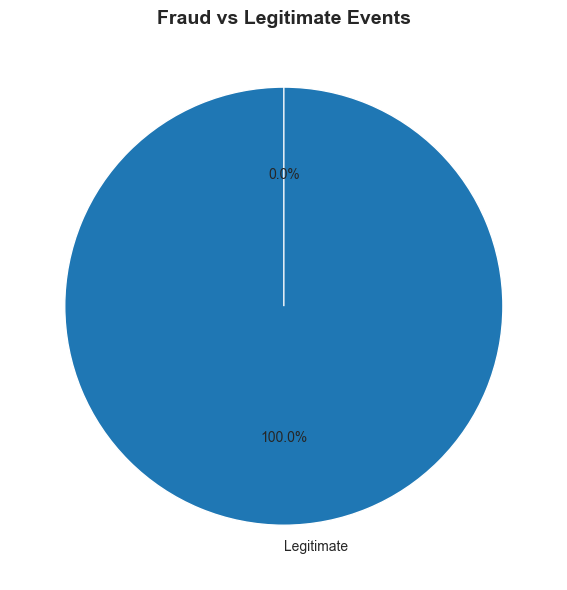

In [33]:
# Fraud detection summary
if 'is_fraud' in df.columns:
    fraud_summary = pd.DataFrame({
        'Count': [
            (df['is_fraud'] == False).sum(),
            (df['is_fraud'] == True).sum(),
            len(df)
        ],
        'Percentage': [
            (df['is_fraud'] == False).sum() / len(df) * 100,
            (df['is_fraud'] == True).sum() / len(df) * 100,
            100
        ]
    }, index=['Legitimate', 'Fraudulent', 'Total'])
    
    print("🛡️ Fraud Detection Summary:")
    fraud_summary
    
    # Visualize
    plt.figure(figsize=(8, 6))
    fraud_summary['Count'].head(2).plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title('Fraud vs Legitimate Events', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


In [35]:
# Fraud signals analysis
if 'fraud_signals' in df.columns:
    # Extract all fraud signals
    all_signals = []
    for signals in df['fraud_signals'].dropna():
        if isinstance(signals, list):
            all_signals.extend(signals)
    
    if all_signals:
        signal_counts = pd.Series(all_signals).value_counts().head(10)
        
        plt.figure(figsize=(12, 6))
        signal_counts.plot(kind='barh')
        plt.title('Top 10 Fraud Signals', fontsize=14, fontweight='bold')
        plt.xlabel('Count', fontsize=12)
        plt.ylabel('Fraud Signal', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        print("\n📊 Top Fraud Signals:")
        print(signal_counts)
    else:
        print("No fraud signals found in the data.")


No fraud signals found in the data.


## Data Export

Export processed data to CSV for further analysis.


In [36]:
# Export to CSV
output_file = '../data/google_ads_processed.csv'
df.to_csv(output_file, index=False)
print(f"💾 Data exported to: {output_file}")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")


💾 Data exported to: ../data/google_ads_processed.csv
   Rows: 1,000
   Columns: 28


## Additional Analysis

Add your custom analysis here.


In [37]:
# Example: Filter high-cost events
if 'cost_usd' in df.columns:
    high_cost_threshold = df['cost_usd'].quantile(0.95)
    high_cost_events = df[df['cost_usd'] >= high_cost_threshold]
    
    print(f"💰 High-Cost Events (Top 5%):")
    print(f"   Threshold: ${high_cost_threshold:.2f}")
    print(f"   Count: {len(high_cost_events):,}")
    print(f"\n   Top 10 by cost:")
    high_cost_events.nlargest(10, 'cost_usd')[['event_id', 'campaign_name', 'keyword', 'cost_usd', 'fraud_score']]


💰 High-Cost Events (Top 5%):
   Threshold: $22.38
   Count: 51

   Top 10 by cost:
